# Lecture 4
We will now look at ways to run a computational process and monitor it as it performs the assigned task. At some moment our algorithm will decide that solution progressed enough to make some decision and will restart it with parameters changed according to what we programmed. The task itself, the communication and the process will vary greatly from case to case, but in general we will need to:
* Start an external application with proper command line arguments.
    * This can be done either in a blocking (the thread serving our Python console will not be accessible, and will lock for the execution of the called program)
    * Or in a nonblocking way, by spawning a separate process to deal with the problem, while our Python console will return control for us to perform various tasks.
* Read data from a file to which the program stores the interesting value.
* Modify settings of the program, either via command line arguments or a setting file.
* Make decisions on what to do next.

**Note**: I use more less this approach to (attempt) track the edge that possibly exists between the laminar and turbulent solution, by iteratively changing perturbation applied to the flow end examining its evolution in time, on the way deciding if the flow is going turbulent or not. The process is very much like trying to push the ball to land on the top of a hill, push it to hard and it passes to the other side, be to gentle and it will not reach the top. But in an infinite number of dimensions (before discretization).

## The model program
For a given task you will need to use a specific program. For me this is a flow solver, for you it might be ANSYS or ADAMS or something completely different. For the purpose of this presentation we will use a simple C++ program, attached to this repository. (This might not be working with MyBinder though). This program:
* stores a random value from a selected range to a file - our data.
* accepts some simple command line arguments.
* Reads a simplistic setting file.
* The source is in the tick-tick folder.

Start by building the `tick-tick` program.

## Use `os.system` call
We start by simply calling the system command, in our case it is our program. To do this we need to import `os` module:

In [1]:
import os

In [2]:
ls

 1ae52h-1645369074.jpg   defunct_proces.png   settings    tick-tick/
 data.dat               'Lecture 4.ipynb'     skrypt.py


In [4]:
os.system('ls -l')

total 564
-rw-rw-r-- 1 sgepner sgepner 114434 mar 25 11:18 1ae52h-1645369074.jpg
-rw-rw-r-- 1 sgepner sgepner    307 kwi  9  2024 data.dat
-rw-rw-r-- 1 sgepner sgepner 110351 kwi  9  2024 defunct_proces.png
-rw-rw-r-- 1 sgepner sgepner 334223 kwi  1 12:25 Lecture 4.ipynb
-rw-rw-r-- 1 sgepner sgepner     47 mar 27  2024 settings
-rw-rw-r-- 1 sgepner sgepner     96 mar 26  2024 skrypt.py
drwxrwxr-x 5 sgepner sgepner   4096 mar 25 13:30 tick-tick


0

Our test program will be a simple program. The source is given here for the sake of completeness:

In [ ]:
cat ./tick-tick/main.cpp

We start with the simple call to `os.system`. OS is a module that lets our Python script interact with the operating system, and the `system()` method executes the command (a string) in a subshell. It is a blocking call, meaning for the time of execution the console is unusable.

In [7]:
os.system('./tick-tick/build/tick-tick')
# os.system('./tick-tick/build_debug/tick-tick --period 10')

===== Starting process =====
Period:1000
Dt:	0.1
Xmax:	1
Xmin:	-1
N:	10


0

In [8]:
ls

 1ae52h-1645369074.jpg   defunct_proces.png   settings    tick-tick/
 data.dat               'Lecture 4.ipynb'     skrypt.py


In [9]:
os.system('./tick-tick/build/tick-tick --period 10')

===== Starting process =====
Period:10
Dt:	0.1
Xmax:	1
Xmin:	-1
N:	10


0

This executes `tick-tick` program, the working directory (place where work is performed) is the same as our current working directory. As a result `data.dat` should appear. The file content is:

In [10]:
cat data.dat

# Recording precious random data
# t, value
# Settings: 10 0.1 1 -1 10
0,	 -0.736924
0.1,	 -0.0826997
0.2,	 -0.562082
0.3,	 0.357729
0.4,	 0.869386
0.5,	 0.0388327
0.6,	 -0.930856
0.7,	 0.0594004
0.8,	 -0.984604
0.9,	 -0.866316


In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
t, v = np.loadtxt('data.dat', comments="#", skiprows=3, usecols=(0,1), unpack=True, delimiter=',')

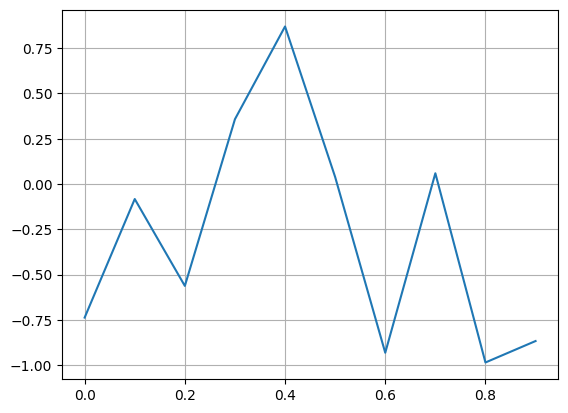

In [13]:
plt.plot(t, v)
plt.grid()

Before proceeding lets add setting file we can manipulate:

In [14]:
f = open('./settings', 'w')
f.writelines('DT   = 0.5\n')
f.write('XMAX = 5.0\n')
f.write('XMIN = -5.0\n')
f.write('N    = 1000\n')
f.close()

In [15]:
ls

 1ae52h-1645369074.jpg   defunct_proces.png   settings    tick-tick/
 data.dat               'Lecture 4.ipynb'     skrypt.py


In [16]:
cat settings

DT   = 0.5
XMAX = 5.0
XMIN = -5.0
N    = 1000


Now we have a settings file to be passed to our process.

In [17]:
os.system('./tick-tick/build/tick-tick --period 10 --sett settings')

===== Starting process =====
Period:10
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	1000


0

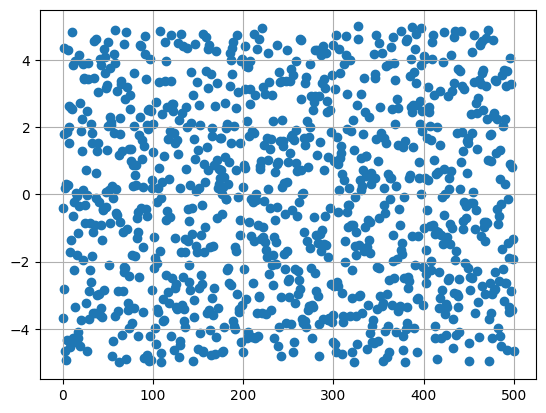

In [18]:
t, v = np.loadtxt('data.dat', comments="#", skiprows=2, usecols=(0,1), unpack=True, delimiter=',')
plt.scatter(t, v)
plt.grid()

## `subprocess`
### Blocking call:
Ultimately we would like to run the program and regain control, while the program runs. To this end we will use the `subprocess` module and a couple of `os` tools. The `subprocess` module allows to create new processes, obtain their returns and outputs. We will show only some of the functionality. Let's start with getting the output with `check_output`, that we can later parse and use:

In [19]:
import subprocess

In [20]:
ls -l

total 688
-rw-rw-r-- 1 sgepner sgepner 114434 mar 25 11:18  1ae52h-1645369074.jpg
-rw-rw-r-- 1 sgepner sgepner  15482 kwi  1 12:28  data.dat
-rw-rw-r-- 1 sgepner sgepner 110351 kwi  9  2024  defunct_proces.png
-rw-rw-r-- 1 sgepner sgepner 448253 kwi  1 12:29 'Lecture 4.ipynb'
-rw-rw-r-- 1 sgepner sgepner     46 kwi  1 12:28  settings
-rw-rw-r-- 1 sgepner sgepner     96 mar 26  2024  skrypt.py
drwxrwxr-x 5 sgepner sgepner   4096 mar 25 13:30  tick-tick/


In [21]:
s = subprocess.check_output(["ls", "-l"])

In [24]:
print(s)

b'total 688\n-rw-rw-r-- 1 sgepner sgepner 114434 mar 25 11:18 1ae52h-1645369074.jpg\n-rw-rw-r-- 1 sgepner sgepner  15482 kwi  1 12:28 data.dat\n-rw-rw-r-- 1 sgepner sgepner 110351 kwi  9  2024 defunct_proces.png\n-rw-rw-r-- 1 sgepner sgepner 448253 kwi  1 12:29 Lecture 4.ipynb\n-rw-rw-r-- 1 sgepner sgepner     46 kwi  1 12:28 settings\n-rw-rw-r-- 1 sgepner sgepner     96 mar 26  2024 skrypt.py\ndrwxrwxr-x 5 sgepner sgepner   4096 mar 25 13:30 tick-tick\n'


In [25]:
for ss in s.splitlines():
    print(ss)

b'total 688'
b'-rw-rw-r-- 1 sgepner sgepner 114434 mar 25 11:18 1ae52h-1645369074.jpg'
b'-rw-rw-r-- 1 sgepner sgepner  15482 kwi  1 12:28 data.dat'
b'-rw-rw-r-- 1 sgepner sgepner 110351 kwi  9  2024 defunct_proces.png'
b'-rw-rw-r-- 1 sgepner sgepner 448253 kwi  1 12:29 Lecture 4.ipynb'
b'-rw-rw-r-- 1 sgepner sgepner     46 kwi  1 12:28 settings'
b'-rw-rw-r-- 1 sgepner sgepner     96 mar 26  2024 skrypt.py'
b'drwxrwxr-x 5 sgepner sgepner   4096 mar 25 13:30 tick-tick'


For us, more useful is `call()`. It runs command passed as argument and waits (locks control) until command completes. 

In [32]:
com = "tick-tick/build/tick-tick"
subprocess.call(com)

===== Starting process =====
Period:1000
Dt:	0.1
Xmax:	1
Xmin:	-1
N:	10


0

In [28]:
ls

 1ae52h-1645369074.jpg   defunct_proces.png   settings    tick-tick/
 data.dat               'Lecture 4.ipynb'     skrypt.py


If additional parameters need to be passed:

In [33]:
com = "tick-tick/build/tick-tick --period 50 --sett settings"
subprocess.call(com, shell=True)

===== Starting process =====
Period:50
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	1000


0

Note the additional `shell=True` argument. This specifies that the command will be executed through the system shell (eg. Bash) and is useful if we need to pass arguments. We can illustrate the result:

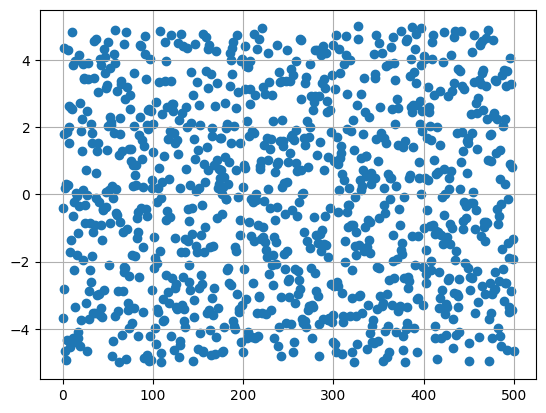

In [34]:
t, v = np.loadtxt('data.dat', comments="#", skiprows=2, usecols=(0,1), unpack=True, delimiter=',')
plt.scatter(t, v)
plt.grid()

Example: Using the `tick-tick` program and the `call` function write a script that runs the `tick-tick` changing the number of iterations N and plots average and variance as functions of N.

1. Write a function that modifies the setting file accordingly.
2. Write a function that reads the result file and stores the results.
3. Run the process in a loop, choose some stopping criteria.

In [36]:
more settings

In [37]:
def settfile(fname, N):
    '''
    Modifies the setting file
    param: fname - file to modify
    param: N - nuber of iteration do perform
    '''
    f = open(fname, 'w')
    f.writelines('DT   = 0.5\n')
    f.write('XMAX = 5.0\n')
    f.write('XMIN = -5.0\n')
    st =    'N    = ' + str(N) + '\n'
    f.write(st)
    f.close()

In [38]:
def calculate(fname):
    '''
    Using fname calculates average and variance
    '''
    t, v = np.loadtxt(fname, comments="#", skiprows=3, usecols=(0,1), unpack=True, delimiter=',')
    s = v.sum()
    avg = s / len(t)
    s = 0
    for val in v:
        s += (val - avg)**2
    var = s / len(t)
    return avg, var

In [41]:
'''
Run the process here
'''
n = []
av = []
va = []
for N in range(5,10000,50):
    st = 'settings'
    settfile(st, N)
#     print('Running for N=', N)
    subprocess.call("tick-tick/build/tick-tick --period 0 --sett settings", shell=True)
    a, v = calculate('data.dat')
    n.append(N)
    av.append(a)
    va.append(v)
    if N > 100 and np.abs(a) < 1.0e-3: # stopping cryteria
        break
#     print(a, v)

===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	5
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	55
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	105
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	155
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	205
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	255
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	305
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	355
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	405
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	455
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	505
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	555
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	605
===== Starting process =====
Period:0
Dt:	0.5
Xmax:	5
Xmin:	-5
N:	655
===== Starting process 

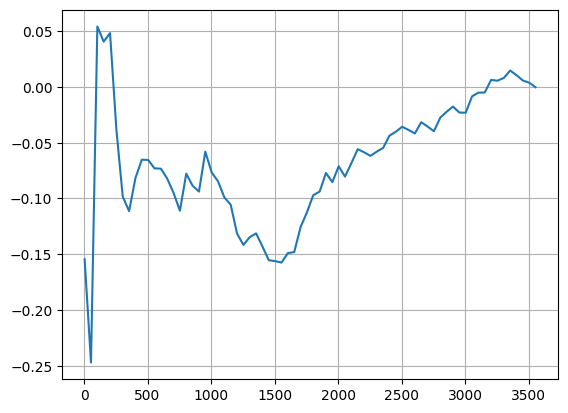

In [42]:
plt.plot(n, av)
plt.grid()

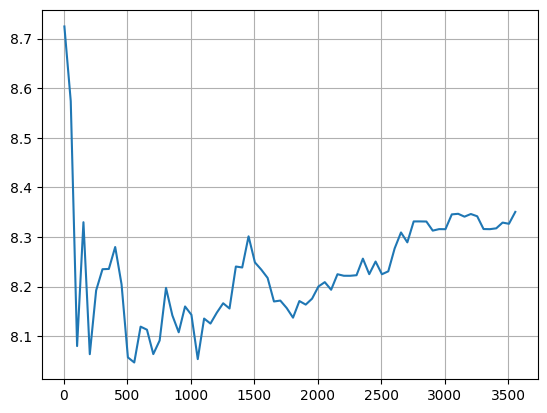

In [43]:
plt.plot(n, va)
plt.grid()

### Run and regain control with `popen()`
We will now look at a slight modification. Our goal is to be able to monitor (programmatically) the process we call and if necessary make decision, change parameters and eventually stop execution or restart. To do this we need to add a couple of things to our tool set. Fist is the `subprocess.Popen()`, which works very much like `call()`, with a difference that it executes the child (**without mercy!**) in a new process! What that means is that new, separate from our Python interpreter, process is started to handle the program, and control is returned to the interpreter to perform whatever task we wish it to do. When called `Popen` object is returned. We will outline some of functionality it provides (also see the documentation).

**The most important feature is that `Popen()` allows a nonblocking call!** meaning we can continue interacting with our script

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import time
from IPython.display import clear_output
import os

Note: It is good to show the process tree at this moment.

In [129]:
cmd = 'tick-tick/build/tick-tick'
p=subprocess.Popen(cmd)

In [130]:
print(p) # object of class popen

<Popen: returncode: None args: 'tick-tick/build/tick-tick'>


In [131]:
for i in range(0,10):
    clear_output(wait=True)
    print(i, end='\n')
    os.system('tail data.dat')
    time.sleep(1)
# p.wait()

9
0,	 -0.736924
0.1,	 -0.0826997
0.2,	 -0.562082
0.3,	 0.357729
0.4,	 0.869386
0.5,	 0.0388327
0.6,	 -0.930856
0.7,	 0.0594004
0.8,	 -0.984604
0.9,	 -0.866316


`p` is going to be a `Popen` with which we (or our smart algorithm) can interact. There is a number of things we could do. The most important is to check if the child process is alive (`Popen.poll()`), wait for it to finish with (`Popen.wait(timeout)`), or send it a signal for termination or kill (`Popen.terminate() .kill()`). There is also an option to interact with the process passing data to `stdin` and to read from `stdout` with `Popen.communicate()`, but our program does not support this (you can try it out).

Examine:
* `p.poll()`
* `p.wait()`
* `p.pid`
* `p.terminate()` and `p.kill()`

Note: `terminate` will send `SIGTERM`, while `kill` will result in `SIGKILL` on Linux.

Note: Why `wait()` the process?
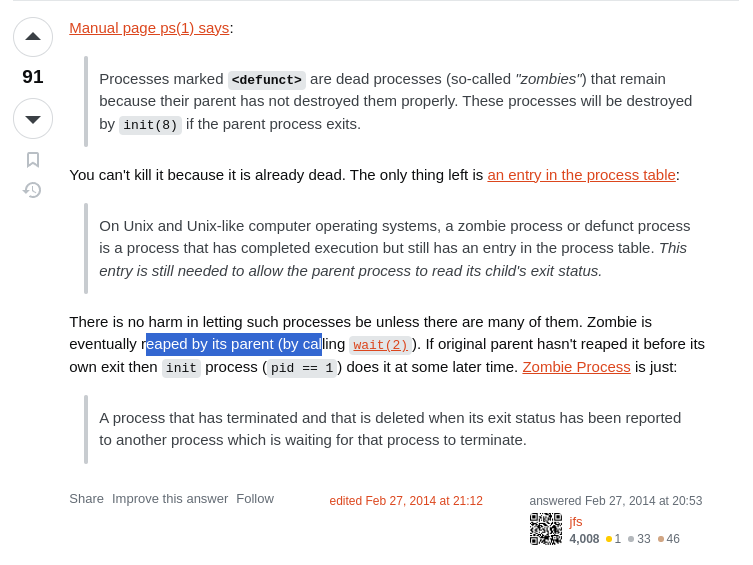

Let us see:

In [16]:
cmd = 'tick-tick/build/tick-tick'
p=subprocess.Popen(cmd)

In [23]:
pid = p.pid
poll = p.poll()
print(poll)

if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

0
Tick-tick has finished with code: 0 and return code= 0


In [18]:
p.wait()

pid = p.pid
poll = p.poll()
print(poll)

if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

===== Starting process =====
Period:1000
Dt:	0.1
Xmax:	1
Xmin:	-1
N:	10
0
Tick-tick has finished with code: 0 and return code= 0


`wait()` without any arguments will lock and wait for the process to finish. Passing a `timeout` argument will result in `wait()` raising an error if the process does not finish. We can capture and deal with this using the `try` and `except` construct. (similar to `try` and `catch`).

In [27]:
cmd = 'tick-tick/build/tick-tick'
p=subprocess.Popen(cmd)

In [24]:
p.wait(timeout=1)

0

In [26]:
try:
    print(p.wait(timeout=2))
except:
    print('some error!')

some error!
===== Starting process =====
Period:1000
Dt:	0.1
Xmax:	1
Xmin:	-1
N:	10


In [30]:
pid = p.pid
poll = p.poll()
print(poll)

0


In [31]:
if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

p.wait()
    
if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

Tick-tick has finished with code: 0 and return code= 0
Tick-tick has finished with code: 0 and return code= 0


### Killing the p
There is nothing more pleasurable than to destroy something ...

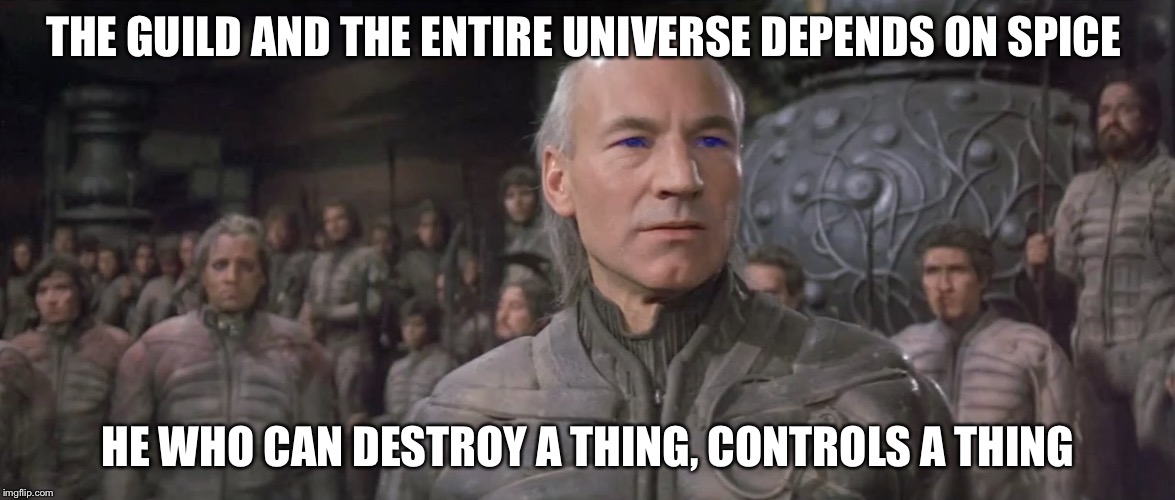

"He who can destroy a thing has the real control of it." Paul Atreides

In [46]:
cmd = 'tick-tick/build/tick-tick'
p=subprocess.Popen(cmd)

In [47]:
pid = p.pid
poll = p.poll()
print(poll)
if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

None
Tick-tick is still running, pid= 255500


In [48]:
# p.kill()
p.terminate()

In [49]:
p.wait()

-15

In [50]:
os.system('tail data.dat')

# Recording precious random data
# t, value
# Settings: 1000 0.1 1 -1 10


0

In [25]:
pid = p.pid
poll = p.poll()
print(poll)
if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

-15
Tick-tick has finished with code: -15 and return code= -15


How about the `shell=True` option, that we need when passing command line settings?

**Note**: Note additional process spawned to handle our call!

In [137]:
cmd = "tick-tick/build/tick-tick --period 1000 --sett settings"
p=subprocess.Popen(cmd, shell=True)
# p=subprocess.Popen(cmd)

In [142]:
pid = p.pid
poll = p.poll()
print(poll)
if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

None
Tick-tick is still running, pid= 268438


In [143]:
p.kill()

In [89]:
cmd = 'kill ' + str(pid+1)
print(cmd)

kill 259417


In [90]:
os.system(cmd)

sh: 1: kill: No such process



256

In [91]:
p.wait()

-9

In [153]:
os.system('tail data.dat')

45.5,	 4.31674
46,	 -2.84752
46.5,	 4.08922
47,	 3.6086
47.5,	 0.0595588
48,	 3.17561
48.5,	 -0.37755
49,	 1.32739
49.5,	 3.24697
50,	 2.02207


0

In [62]:
pid = p.pid
poll = p.poll()
print(poll)
if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

-9
Tick-tick has finished with code: -9 and return code= -9


Process is not dead!! This is because `kill()` killed the shell process, we invoked to process our call with additional options, and not the actual command, which is now a process without a parent, but a still running one. An easy fix is to add `exec` before the actual command we wish to run:

**Note**: *`exec` command in Linux is used to execute a command from the bash itself. This command does not create a new process it just replaces the bash with the command to be executed. If the exec command is successful, it does not return to the calling process.*

In [99]:
cmd = "exec tick-tick/build/tick-tick --period 1000 --sett settings"
p=subprocess.Popen(cmd, shell=True)

In [100]:
pid = p.pid
poll = p.poll()
print(poll)
if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

None
Tick-tick is still running, pid= 260749


In [112]:
p.kill()

In [111]:
os.system('tail data.dat')

10.5,	 2.53356
11,	 -4.27314
11.5,	 3.84707
12,	 -0.635886
12.5,	 -0.222682
13,	 -2.25093
13.5,	 -3.33493
14,	 3.97656
14.5,	 -4.39436
15,	 0.0452289


0

In [96]:
p.wait()

-9

In [115]:
pid = p.pid
poll = p.poll()
print(poll)
if poll == None:
    print('Tick-tick is still running, pid=', pid)
else:
    print('Tick-tick has finished with code:', poll, 'and return code=', p.returncode)

-9
Tick-tick has finished with code: -9 and return code= -9


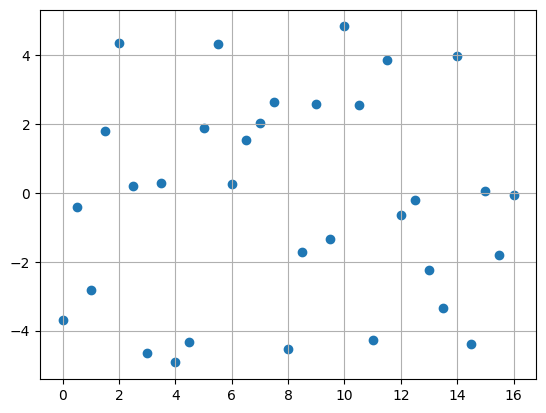

In [116]:
t, v = np.loadtxt('data.dat', comments="#", skiprows=2, usecols=(0,1), unpack=True, delimiter=',')
plt.scatter(t, v)
plt.grid()

### Example
Run the `tick-tick` program checking the average value and stopping the execution when the value reaches a certain, satisfactory value and stays there for some time.

In [117]:
import time

In [118]:
def calculate(fname):
    '''
    Using fname calculates average and variance
    '''
    t, v = np.loadtxt(fname, comments="#", skiprows=3, usecols=(0,1), unpack=True, delimiter=',')
    s = v.sum()
    avg = s / len(t)
    s = 0
    for val in v:
        s += (val - avg)**2
    var = s / len(t)
    return avg, var

In [126]:
cat settings

DT   = 0.5
XMAX = 5.0
XMIN = -5.0
N    = 10000


In [127]:
'''
Run the process here
'''
p=subprocess.Popen('exec tick-tick/build/tick-tick --period 10 --sett settings', shell=True)

In [ ]:
nn = []
av = []
while True:
    if p.poll() != None:
        print(p.pid, 'Is not working')
        break
    time.sleep(3)
    
    a, v = calculate('data.dat')
    nn.append(len(av))
    av.append(a)
    print(len(av), a)
    if np.abs(a) < 1e-5:
        p.terminate()
        print(p.pid, 'is now dead')

plt.plot(nn, av)
plt.grid()

1 -0.07172722702272726
2 -0.10492325025885556
3 -0.09042627499025344
4 -0.14009525150871874
5 -0.14373567607940446
6 -0.07529141874474789
7 -0.05801800309057805
8 -0.03597112413253011
9 -0.029163484876033055
10 -0.010666913011382109
11 0.016659992894893116
12 -0.0012179846067722545
13 0.011569608679817897
14 0.0007096941417471197
15 0.013367816568281938
16 0.009700754173391276
17 -0.0043568533710495435
18 -0.009364624785015676
19 -0.019705019280336182
20 -0.01628357158701083
21 -0.008625427846935537
22 -0.005378794671521773
23 -0.006611591995932602
24 -0.014450803929765886
25 -0.009668189516668889
26 -0.012642303913155512
27 -0.006758631119801362
28 -0.008475839938900191
29 -0.009582246900821653
30 -0.008356431050039168
31 -0.010009143561673522
32 -0.008425152539915956
